<a href="https://colab.research.google.com/github/dindahanifa/mechine_learning/blob/main/prediksi_harga_laptop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A. Persiapan & Load Dataset


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [13]:
data = pd.read_csv("laptop_prices.csv")

print("Preview data:")
# Format 'Price_Million_IDR' to Rupiah
data['Price_Million_IDR_Formatted'] = (data['Price_Million_IDR'] * 1_000_000).apply(lambda x: f'Rp {x:,.2f}')
print(data[['Brand', 'Processor_Type', 'RAM_GB', 'Storage_GB', 'Storage_Type', 'GPU_Type', 'Screen_Size_Inch', 'Weight_KG', 'Battery_Life_Hours', 'Price_Million_IDR_Formatted']].head())

print("\nInfo kolom:")
print(data.info())

print("\nStatistik deskriptif:")
print(data.describe(include='all'))

print("\nChecking for missing values:")
print(data.isnull().sum())

Preview data:
   Brand Processor_Type  RAM_GB  Storage_GB Storage_Type    GPU_Type  \
0  Apple             M1       4         512          SSD  Integrated   
1   Dell             i5       4         256          SSD  Integrated   
2   Acer             i7       8        1024          SSD   Dedicated   
3  Apple             i3      16         256          SSD   Dedicated   
4     HP        Ryzen 5       4         256          SSD   Dedicated   

   Screen_Size_Inch  Weight_KG  Battery_Life_Hours Price_Million_IDR_Formatted  
0              13.5       1.23                 4.2            Rp 64,550,000.00  
1              16.1       2.88                 9.8            Rp 69,710,000.00  
2              15.7       2.75                11.0            Rp 91,380,000.00  
3              16.1       1.90                 5.8            Rp 97,110,000.00  
4              16.8       2.97                 5.3            Rp 70,860,000.00  

Info kolom:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000

In [7]:
price_correlation = correlation_matrix['Price_Million_IDR'].sort_values(ascending=False)
display(price_correlation)

,Price_Million_IDR
Price_Million_IDR,1.000000
RAM_GB,0.970832
Storage_GB,0.215107
Screen_Size_Inch,0.076777
Processor_Type_M2,0.041768
Brand_HP,0.041622
Brand_Acer,0.035151
Battery_Life_Hours,0.030767
Processor_Type_i5,0.023102
Processor_Type_Ryzen 5,0.015852


In [10]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", ascending=False)

print("Top 15 Coefficients:")
print(coef_df.head(15))

print("\nBottom 15 Coefficients:")
print(coef_df.tail(15))

Top 15 Coefficients:
                   Feature  Coefficient
2         Screen_Size_Inch     3.054103
0                   RAM_GB     2.501726
11       Processor_Type_M2     0.935669
4       Battery_Life_Hours     0.801222
1               Storage_GB     0.014893
18        Storage_Type_SSD    -0.006366
5               Brand_Acer    -0.218495
10               Brand_MSI    -0.266788
6              Brand_Apple    -0.389471
8                 Brand_HP    -0.498237
7               Brand_Dell    -0.642605
9             Brand_Lenovo    -0.738210
14  Processor_Type_Ryzen 7    -1.176389
17       Processor_Type_i7    -1.195898
3                Weight_KG    -1.476522

Bottom 15 Coefficients:
                   Feature  Coefficient
18        Storage_Type_SSD    -0.006366
5               Brand_Acer    -0.218495
10               Brand_MSI    -0.266788
6              Brand_Apple    -0.389471
8                 Brand_HP    -0.498237
7               Brand_Dell    -0.642605
9             Brand_Lenovo    -0.7

In [9]:
# Define features (X) and target (y)
X = data_encoded.drop('Price_Million_IDR', axis=1)
y = data_encoded['Price_Million_IDR']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [11]:
data_encoded = pd.get_dummies(
    data,
    columns=["Brand", "Processor_Type", "Storage_Type", "GPU_Type"],
    drop_first=True
)

print("Kolom setelah encoding:")
print(data_encoded.columns)

Kolom setelah encoding:
Index(['RAM_GB', 'Storage_GB', 'Screen_Size_Inch', 'Weight_KG',
       'Battery_Life_Hours', 'Price_Million_IDR', 'Brand_Acer', 'Brand_Apple',
       'Brand_Dell', 'Brand_HP', 'Brand_Lenovo', 'Brand_MSI',
       'Processor_Type_M2', 'Processor_Type_Ryzen 3', 'Processor_Type_Ryzen 5',
       'Processor_Type_Ryzen 7', 'Processor_Type_i3', 'Processor_Type_i5',
       'Processor_Type_i7', 'Storage_Type_SSD', 'GPU_Type_Integrated'],
      dtype='object')


In [14]:
X = data_encoded.drop("Price_Million_IDR", axis=1)
y = data_encoded["Price_Million_IDR"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Ukuran data latih:", X_train.shape)
print("Ukuran data uji  :", X_test.shape)

Ukuran data latih: (800, 20)
Ukuran data uji  : (200, 20)


In [16]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Contoh prediksi vs aktual:")
for i in range(5):
    print(f"Prediksi: {round(y_pred[i],2)}  |  Aktual: {y_test.iloc[i]}")

Contoh prediksi vs aktual:
Prediksi: 145.37  |  Aktual: 148.4
Prediksi: 102.47  |  Aktual: 101.59
Prediksi: 136.95  |  Aktual: 132.27
Prediksi: 68.63  |  Aktual: 69.52
Prediksi: 114.31  |  Aktual: 115.97


Rata-rata Residu: -0.21


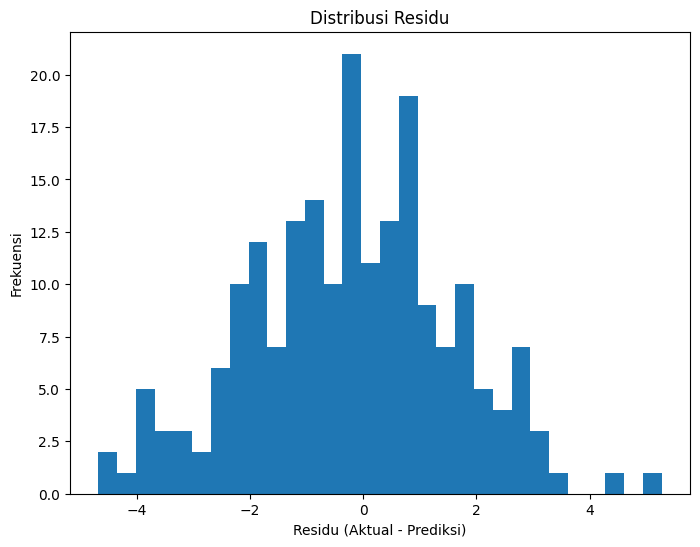

In [17]:
residuals = y_test - y_pred
mean_residual = residuals.mean()

print(f"Rata-rata Residu: {mean_residual:.2f}")

# Optional: Plot the distribution of residuals
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=30)
plt.title('Distribusi Residu')
plt.xlabel('Residu (Aktual - Prediksi)')
plt.ylabel('Frekuensi')
plt.show()

In [18]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import math

r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = math.sqrt(mean_squared_error(y_test, y_pred))

print("R²   :", r2)
print("MAE  :", mae)
print("RMSE :", rmse)

R²   : 0.9955534874155769
MAE  : 1.4386712471078928
RMSE : 1.8092744781496126


In [19]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", ascending=False)

print(coef_df.head(15))
print(coef_df.tail(15))

                   Feature  Coefficient
2         Screen_Size_Inch     3.054103
0                   RAM_GB     2.501726
11       Processor_Type_M2     0.935669
4       Battery_Life_Hours     0.801222
1               Storage_GB     0.014893
18        Storage_Type_SSD    -0.006366
5               Brand_Acer    -0.218495
10               Brand_MSI    -0.266788
6              Brand_Apple    -0.389471
8                 Brand_HP    -0.498237
7               Brand_Dell    -0.642605
9             Brand_Lenovo    -0.738210
14  Processor_Type_Ryzen 7    -1.176389
17       Processor_Type_i7    -1.195898
3                Weight_KG    -1.476522
                   Feature  Coefficient
18        Storage_Type_SSD    -0.006366
5               Brand_Acer    -0.218495
10               Brand_MSI    -0.266788
6              Brand_Apple    -0.389471
8                 Brand_HP    -0.498237
7               Brand_Dell    -0.642605
9             Brand_Lenovo    -0.738210
14  Processor_Type_Ryzen 7    -1.176389


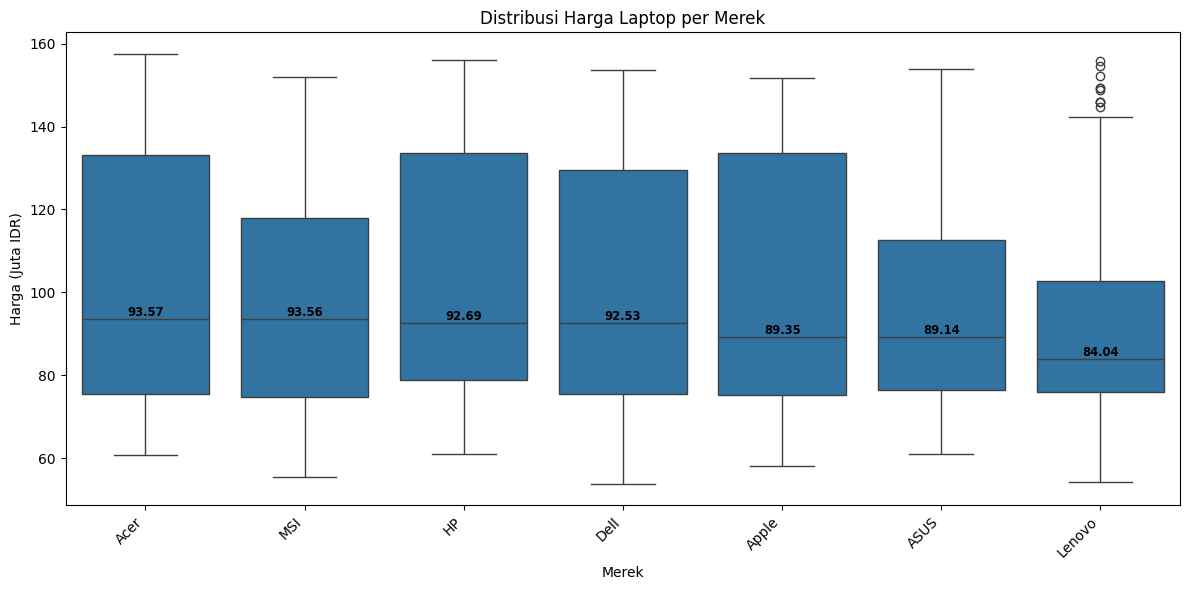

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
ax = sns.boxplot(x='Brand', y='Price_Million_IDR', data=data, order=median_price_by_brand.index) # Use order from median calculation
plt.title('Distribusi Harga Laptop per Merek')
plt.xlabel('Merek')
plt.ylabel('Harga (Juta IDR)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Calculate median prices (already calculated above, but recalculating here for clarity within the cell)
median_price_by_brand = data.groupby('Brand')['Price_Million_IDR'].median().sort_values(ascending=False)

# Add median text labels to the plot
for i, brand in enumerate(median_price_by_brand.index):
    median_val = median_price_by_brand[brand]
    # Get the x-position using the index 'i' since we ordered the boxes
    x_pos = i
    ax.text(x_pos, median_val, f'{median_val:.2f}',
            horizontalalignment='center', size='small', color='black', weight='semibold', va='bottom') # Use va='bottom' to place text above the median line

plt.show()

In [24]:
# Assuming y_test and y_pred are available from previous steps
# If not, re-run the prediction cell first (HpyEFTsk7vQn)
# y_pred = model.predict(X_test)

r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = math.sqrt(mean_squared_error(y_test, y_pred))

print("R²   :", r2)
print("MAE  :", mae)
print("RMSE :", rmse)

R²   : 0.9955534874155769
MAE  : 1.4386712471078928
RMSE : 1.8092744781496126
